# GeoTón Perú 2026 — Notebook 2: Feature Engineering + ML + SHAP

**Entrada**: `output/features_distritales_v1.parquet` (del Notebook 1)

**Salidas**:
- `output/features_distritales_v2.parquet` (con ~17 features adicionales)
- `output/shap_values.parquet` (para el Bloque C — Alkire-Foster con umbrales empíricos)
- `output/feature_importance.csv` (ranking de importancia)
- Plots inline: summary, dependence plots, top distritos

## Estructura

1. **Feature Engineering** — distancias (BallTree+Haversine), dispersión, ratios, interacciones
2. **Modelo predictivo** — LightGBM y XGBoost con CV 5-fold para predecir `pct_nbi`
3. **SHAP — interpretabilidad** — summary global + dependence plots (umbrales para Alkire-Foster) + SHAP local

## 0. Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('src').resolve()))

DATA = Path('data')
OUT = Path('output')
OUT.mkdir(exist_ok=True)
print('OK')

OK


In [2]:
# Cargar la tabla maestra del Notebook 1
df_full = pd.read_parquet(OUT / 'features_distritales_v1.parquet')
print(f'Tabla maestra: {df_full.shape}')

# Cargar los datasets crudos necesarios para feature engineering (KDTree, dispersión)
from utils.limpieza import limpiar_salud
from utils.limpieza_escuelas import limpiar_escuelas
from utils.limpieza_osiptel import limpiar_osiptel

df_sal = limpiar_salud(DATA / 'GeoPeru-instituciones_salud_Peru Instituciones Salud.csv', verbose=False)
df_esc = limpiar_escuelas(DATA / 'GeoPeru-instituciones_educativas.xlsx', verbose=False)
df_ops = limpiar_osiptel(DATA / 'Cobertura móvil por empresa operadora.csv', verbose=False)
print(f'salud: {df_sal.shape}, escuelas: {df_esc.shape}, osiptel: {df_ops.shape}')

Tabla maestra: (1874, 71)
salud: (8967, 17), escuelas: (94049, 23), osiptel: (51366, 15)


## 1. Feature Engineering

Genera ~17 columnas nuevas en 4 grupos:

| Grupo | Variables | Cálculo |
|---|---|---|
| **Distancias** | `km_hospital`, `km_salud_cercano`, `km_colegio`, `km_secundaria`, `n_estab_30km`, `n_colegios_30km` | BallTree + Haversine (distancia esférica real, no euclidiana) |
| **Dispersión** | `n_ccpp_distrito`, `std_lat_ccpp`, `std_lon_ccpp`, `radio_distrito_km` | Std de coordenadas de CCPP del distrito (OSIPTEL) |
| **Ratios** | `habitantes_por_estab_salud/hospital/secundaria/escuela` | total_pers / n_servicio |
| **Interacciones** | `indice_aislamiento`, `ratio_rural`, `desierto_compuesto` | Productos conceptualmente relevantes |

In [3]:
from utils.feature_engineering import enriquecer_features

df_full = enriquecer_features(df_full, df_sal, df_esc, df_ops)

FEATURE ENGINEERING

--- 1. Distancias (BallTree + Haversine) ---
[dist_salud] distritos procesados:     1874
[dist_salud] km_salud_cercano: media=5.1, max=95.9
[dist_salud] km_hospital:      media=36.4, max=354.4
[dist_salud] n_estab_30km:     media=57.8, max=508
[dist_esc] distritos procesados:     1874
[dist_esc] km_colegio:     media=3.3, max=61.1
[dist_esc] km_secundaria:  media=5.2, max=95.5

--- 2. Dispersión territorial (CCPP de OSIPTEL) ---
[dispersion] distritos:              1664
[dispersion] media n_ccpp:          18.9
[dispersion] max n_ccpp:            187
[dispersion] radio promedio (km):   17.5

--- 3. Ratios per capita ---
[ratios] habitantes_por_estab_salud: mediana=1100
[ratios] habitantes_por_hospital:    mediana=3664
[ratios] habitantes_por_secundaria:  mediana=1027

--- 4. Interacciones / variables compuestas ---
[interacciones] columnas creadas: ['indice_aislamiento', 'ratio_rural']
  indice_aislamiento: media=35.15, max=352.89
  ratio_rural: media=23.00, max=100

In [4]:
# Inspección rápida
print(f'Shape: {df_full.shape}')
print(f'Nulos: {df_full.isna().sum().sum()}')
df_full[['nom_dpto','nom_dist','pct_nbi','km_hospital','km_colegio',
         'indice_aislamiento']].head(10)

Shape: (1874, 87)
Nulos: 844


,nom_dpto,nom_dist,pct_nbi,km_hospital,km_colegio,indice_aislamiento
0,APURIMAC,JOSE MARIA ARGUEDAS,22.3,16.54,3.61,15.89
1,APURIMAC,TINTAY,31.1,38.03,0.75,34.85
2,APURIMAC,HUAYANA,20.2,41.14,2.29,40.67
3,APURIMAC,CHAPIMARCA,60.7,45.75,0.70,45.37
4,APURIMAC,COLCABAMBA,9.4,39.29,1.18,39.29
5,APURIMAC,JUAN ESPINOZA MEDRANO,49.3,89.39,7.99,89.13
6,APURIMAC,COTARUSE,37.5,75.11,5.22,75.11
7,APURIMAC,ANTABAMBA,43.8,72.31,4.76,71.62
8,APURIMAC,LUCRE,32.0,32.42,1.68,31.67
9,APURIMAC,SAN MIGUEL DE CHACCRAMPA,42.2,41.83,0.93,41.83


In [5]:
# Guardar para uso posterior
df_full.to_parquet(OUT / 'features_distritales_v2.parquet', index=False)
print('Guardado v2.parquet')

Guardado v2.parquet


## 2. Modelo predictivo

Target: `pct_nbi`. Excluimos del modelo:
- **5 NBI individuales** (`nbi1_porc...nbi5_porc`) → son componentes del target = data leakage
- **IDs y nombres** (cod_dist, nom_dpto, etc.)
- **`pct_nbi`** (es el target)
- **Coordenadas crudas** (lat_centroide, lon_centroide) → introducen señal espacial pura no interpretable
- **Cualquier columna no numérica** que sobreviva

In [6]:
# Definir target y excluir features problemáticas
EXCLUIR = {
    'pct_nbi',  # target
    # NBI individuales (leakage)
    'nbi1_porc', 'nbi2_porc', 'nbi3_porc', 'nbi4_porc', 'nbi5_porc',
    # IDs y nombres
    'cod_dist', 'cod_dpto', 'cod_prov',
    'nom_dist', 'nom_dpto', 'nom_prov',
    # Coordenadas crudas (no aportan al concepto de 'desierto')
    'lat_centroide', 'lon_centroide',
}

# Solo columnas numéricas + no excluidas
FEATURES = [
    c for c in df_full.columns
    if c not in EXCLUIR
    and pd.api.types.is_numeric_dtype(df_full[c])
    or df_full[c].dtype == 'bool'
]
# Filtrar las booleanas y convertir a int
for c in df_full.columns:
    if df_full[c].dtype == 'bool':
        df_full[c] = df_full[c].astype(int)

FEATURES = [c for c in FEATURES if c in df_full.columns and c not in EXCLUIR]
FEATURES = [c for c in FEATURES if pd.api.types.is_numeric_dtype(df_full[c])]

print(f'Total features predictivas: {len(FEATURES)}')
print(FEATURES[:15], '...')

Total features predictivas: 73
['total_pers', 'num_hog', 'sup_tot', 'pct_sin_agua', 'pct_sin_saneamiento', 'pct_sin_luz', 'pct_piso_tierra', 'pct_1_habitacion', 'pct_cocina_lenna', 'pct_sin_pc', 'pct_sin_celular', 'pct_sin_internet', 'pct_hombres', 'pct_0a14', 'pct_15a29'] ...


In [7]:
# Preparar X, y. Eliminar filas con nulos en target o features
df_modelo = df_full.dropna(subset=['pct_nbi'] + FEATURES).copy()
print(f'Filas usables: {len(df_modelo)} / {len(df_full)}')

X = df_modelo[FEATURES]
y = df_modelo['pct_nbi']
print(f'X: {X.shape}, y: {y.shape}')

Filas usables: 1663 / 1874
X: (1663, 73), y: (1663,)


In [8]:
import joblib
import datetime
from pathlib import Path
from utils.tuning_modelos import tunear_todos

CARPETA_MODELOS = OUT / 'modelos'
CARPETA_MODELOS.mkdir(exist_ok=True)
PATH_TUNING = CARPETA_MODELOS / 'tuning_resultados.pkl'


def cargar_o_tunear(X, y, path=PATH_TUNING, forzar=False, **kwargs):
    """
    Cache del tuning de 4 modelos. Si existe el .pkl lo carga;
    si no (o si las features cambiaron) corre tunear_todos y guarda.

    Args:
        X, y:    datos de entrenamiento.
        path:    ruta del .pkl.
        forzar:  True ignora el cache y vuelve a tunear.
        kwargs:  pasan a tunear_todos (n_iter, cv, n_jobs, random_state).
    """
    # --- 1. Intentar cargar cache ---
    if path.exists() and not forzar:
        print(f"📦 Cargando tuning desde cache: {path.name}")
        try:
            resultados = joblib.load(path)
        except Exception as e:
            print(f"⚠️  Error al leer el cache ({e}). Re-tuneando.")
            return cargar_o_tunear(X, y, path, forzar=True, **kwargs)

        # --- 2. Validar que las features no hayan cambiado ---
        features_cache = resultados.get('features', [])
        if features_cache and list(X.columns) != features_cache:
            faltan = set(features_cache) - set(X.columns)
            sobran = set(X.columns) - set(features_cache)
            print(f"⚠️  Las features cambiaron desde el tuning cacheado.")
            print(f"   cache: {len(features_cache)} cols  |  ahora: {len(X.columns)} cols")
            if faltan: print(f"   faltan ahora: {sorted(faltan)[:5]}")
            if sobran: print(f"   nuevas:       {sorted(sobran)[:5]}")
            print("   → Forzando re-tuning")
            return cargar_o_tunear(X, y, path, forzar=True, **kwargs)

        if resultados.get('n_samples') != len(X):
            print(f"⚠️  n cambió ({resultados.get('n_samples')} → {len(X)}). Re-tuneando.")
            return cargar_o_tunear(X, y, path, forzar=True, **kwargs)

        # --- 3. Cache válido ---
        comp = resultados['comparacion']
        print(f"   ✓ Ganador: {resultados['nombre_ganador']}  "
              f"(R²={comp.iloc[0]['R²_mean']:.3f})  "
              f"| guardado: {resultados.get('timestamp', '?')[:19]}")
        return resultados

    # --- 4. No hay cache (o forzar=True): tunear y guardar ---
    estado = "Forzando re-tuning" if forzar else "No hay cache, tuneando"
    print(f"🔧 {estado}...")
    resultados = tunear_todos(X, y, **kwargs)

    # Metadata para validar en futuras corridas
    resultados['features']  = list(X.columns)
    resultados['n_samples'] = len(X)
    resultados['timestamp'] = datetime.datetime.now().isoformat()

    joblib.dump(resultados, path, compress=3)
    size_mb = path.stat().st_size / 1024**2
    print(f"\n💾 Guardado en {path} ({size_mb:.1f} MB)")
    return resultados

In [9]:
# Si el .pkl existe y las features no cambiaron → carga en 1 segundo
# Si no → corre el tuning (10-25 min) y lo guarda
resultados_tuning = cargar_o_tunear(X, y, n_iter=40, cv=5, n_jobs=-1)

comparacion = resultados_tuning['comparacion']
comparacion

📦 Cargando tuning desde cache: tuning_resultados.pkl
   ✓ Ganador: XGBoost  (R²=0.656)  | guardado: 2026-05-24T18:41:41


,modelo,R²_mean,RMSE_mean,RMSE_std,tiempo_s
0,XGBoost,0.656,10.506,0.398,159.563
1,LightGBM,0.651,10.588,0.412,66.044
2,HistGradientBoosting,0.641,10.727,0.479,36.395
3,RandomForest,0.632,10.860,0.484,546.723


Modelo final forzado: XGBoost  |  R² CV = 0.656
SHAP recalculado con XGBoost nativo:
   shap_values shape = (1663, 73)
   base_value promedio = 38.4603
Error máximo |pred_modelo - (sum_shap + base)| = 0.000092 (debe ser cercano a 0)


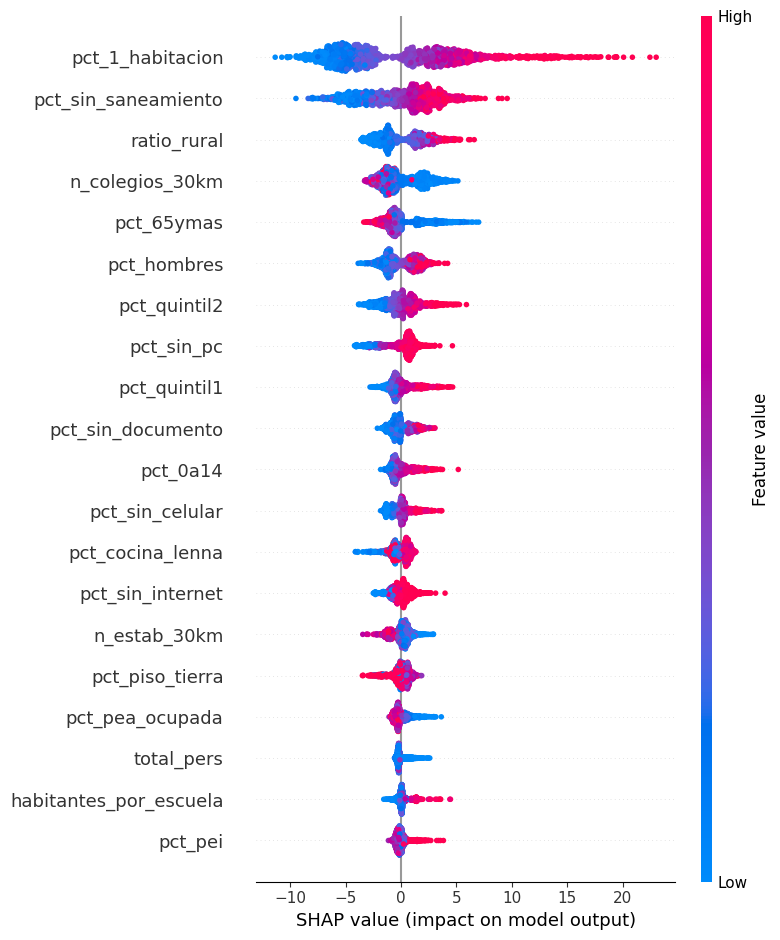

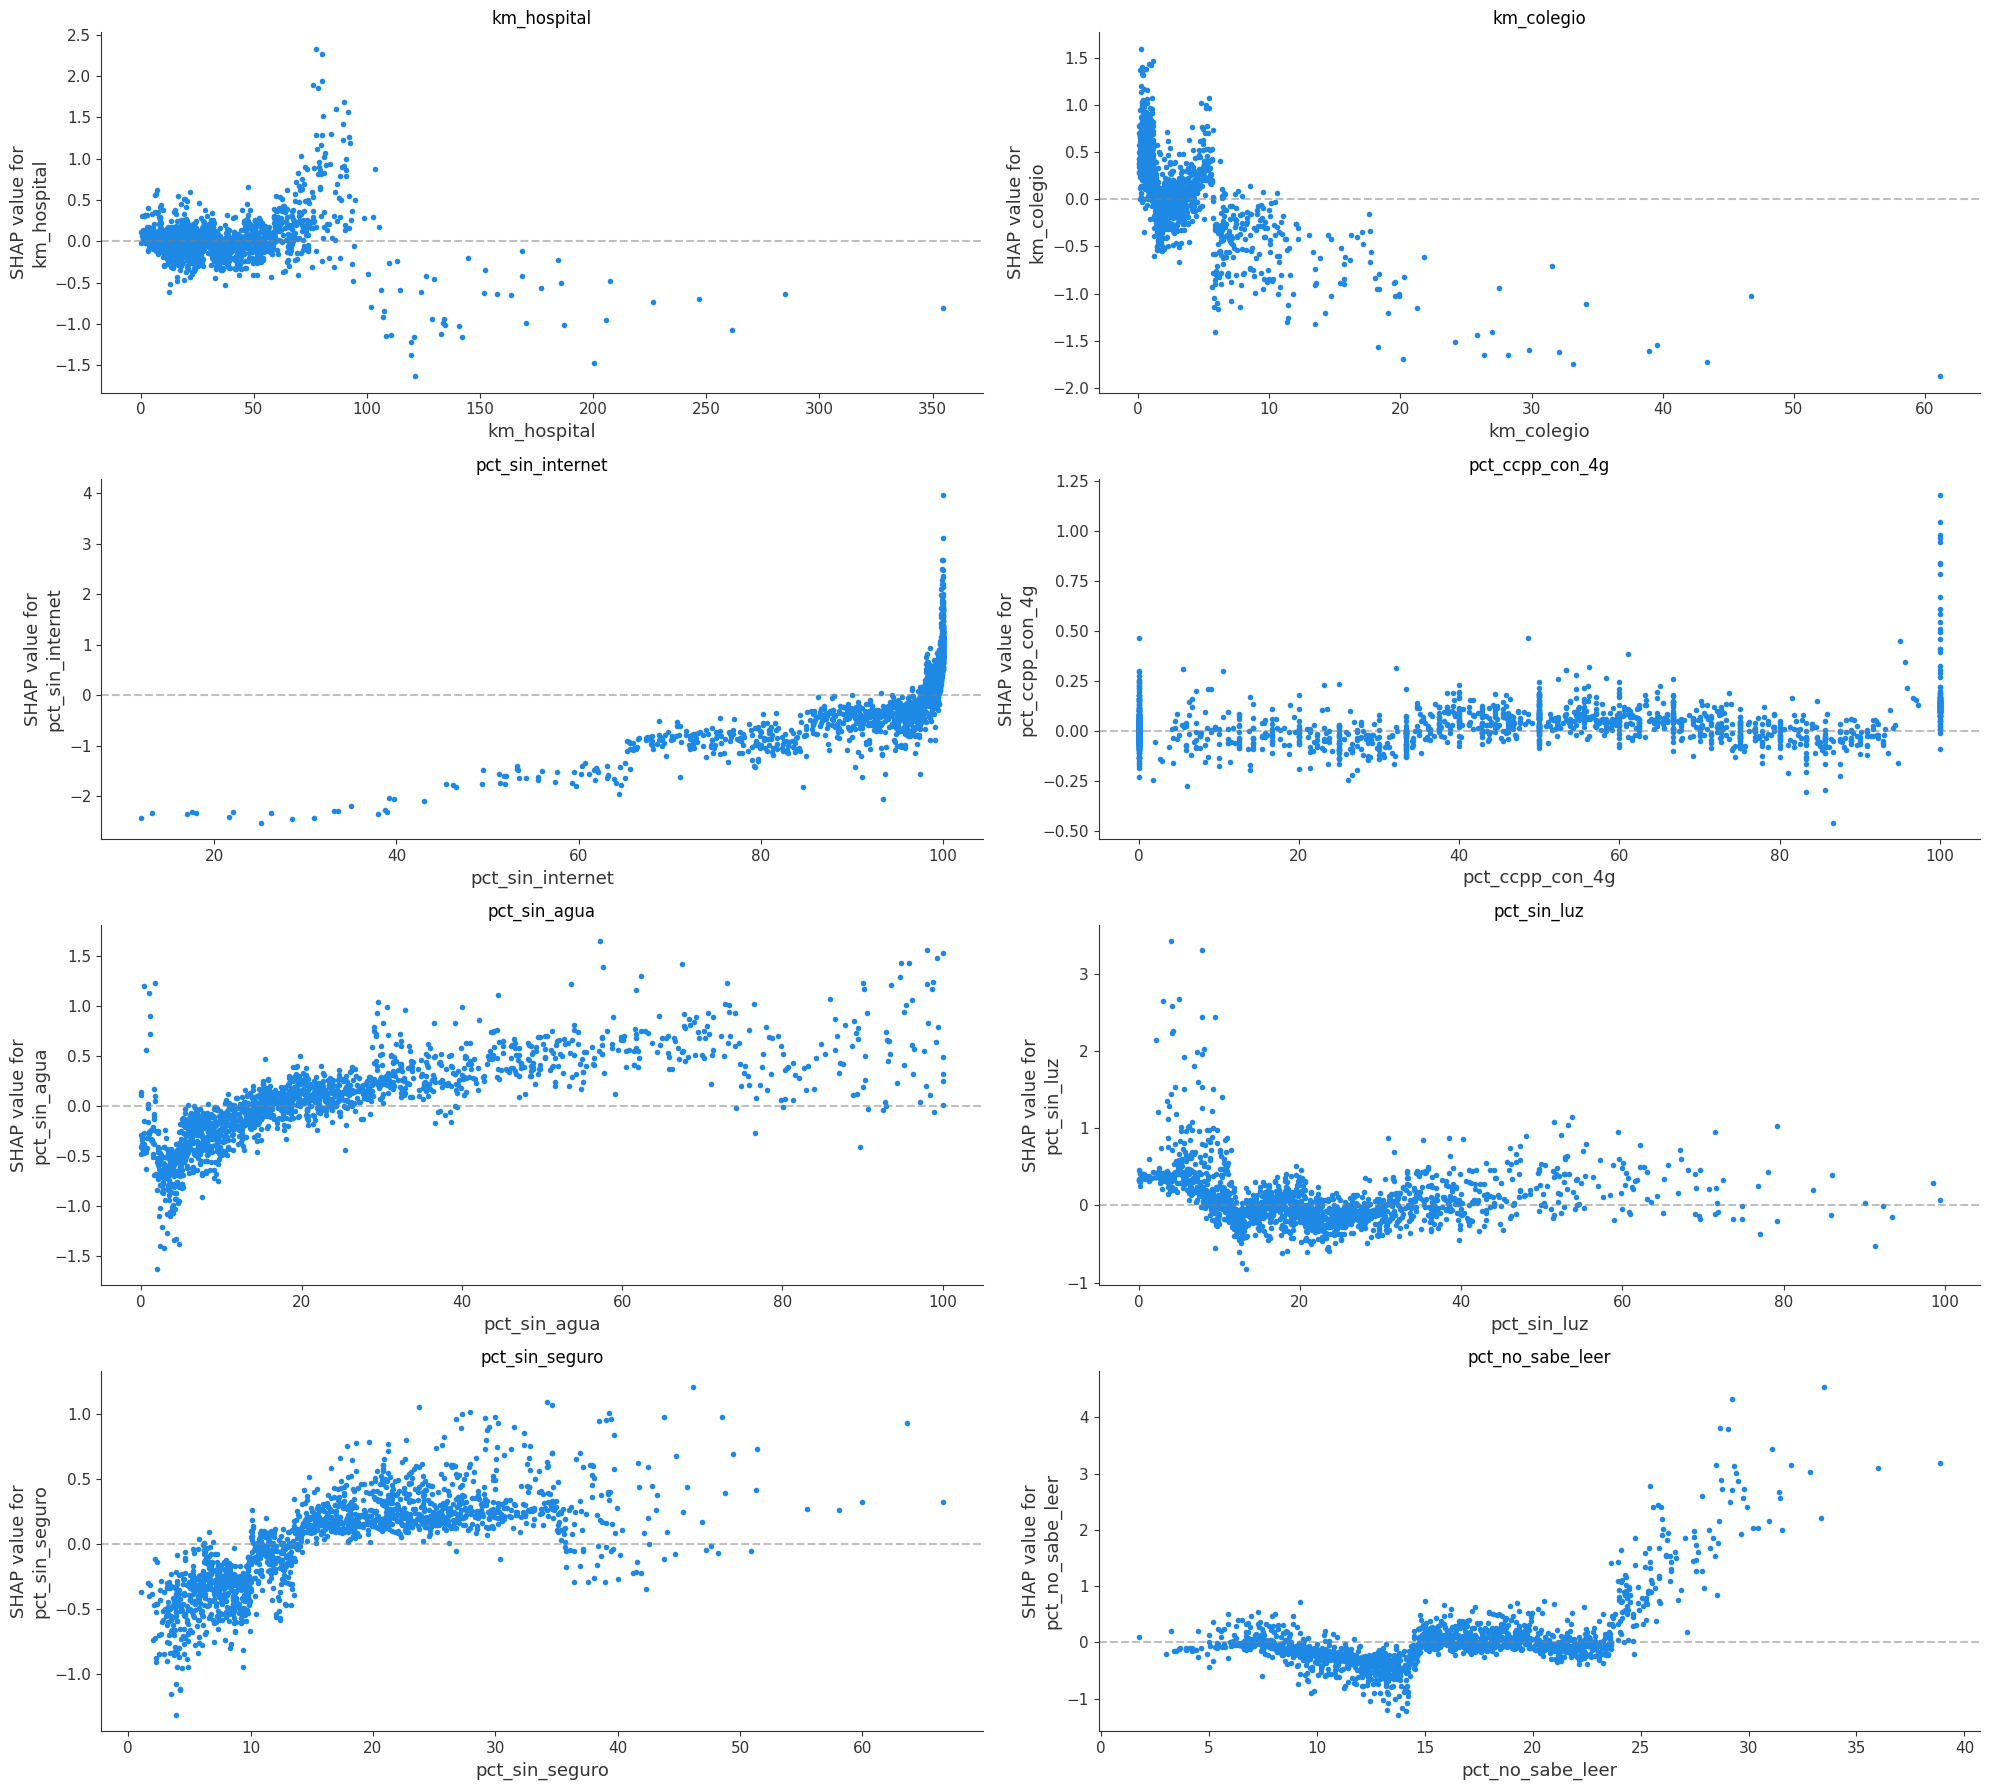


✅ Outputs regenerados con XGBoost:
   - shap_summary.png
   - shap_dependence.png
   - feature_importance.csv  (top: pct_1_habitacion)
   - shap_values.parquet     ((1663, 79))


In [10]:
# ============================================================================
#  RECALCULAR SHAP CON XGBOOST TUNEADO
#  Este bloque fuerza el uso de XGBoost, aunque no sea el ganador global.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

# Features clave para identificar umbrales
FEATURES_UMBRAL = [
    'km_hospital',
    'km_colegio',
    'pct_sin_internet',
    'pct_ccpp_con_4g',
    'pct_sin_agua',
    'pct_sin_luz',
    'pct_sin_seguro',
    'pct_no_sabe_leer',
]

FEATURES_UMBRAL = [f for f in FEATURES_UMBRAL if f in FEATURES]

# ============================================================================
# 1. Seleccionar explícitamente XGBoost tuneado
# ============================================================================

resultado_xgb = next(
    r for r in resultados_tuning['resultados']
    if r['nombre'] == 'XGBoost'
)

modelo_final = resultado_xgb['best_estimator']
nombre_final = 'XGBoost'
r2_final = resultado_xgb['best_r2']

# Entrenar modelo final con todo el dataset
modelo_final.fit(X, y)

print(f'Modelo final forzado: {nombre_final}  |  R² CV = {r2_final:.3f}')

# ============================================================================
# 2. Calcular SHAP values usando XGBoost nativo
# ============================================================================

# XGBoost necesita DMatrix para calcular contribuciones SHAP nativas
dmatrix = xgb.DMatrix(
    X,
    feature_names=list(X.columns)
)

# pred_contribs=True devuelve:
# - columnas 0 hasta n_features-1: SHAP values por feature
# - última columna: base value / bias
contribs = modelo_final.get_booster().predict(
    dmatrix,
    pred_contribs=True
)

shap_values = contribs[:, :-1]
base_values = contribs[:, -1]

# Para reportar un único base value promedio
base_value = float(np.mean(base_values))

print(f'SHAP recalculado con XGBoost nativo:')
print(f'   shap_values shape = {shap_values.shape}')
print(f'   base_value promedio = {base_value:.4f}')

# ============================================================================
# 3. Sanity check: verificar que la descomposición cierre
# ============================================================================

pred_modelo = modelo_final.predict(X)
pred_shap = shap_values.sum(axis=1) + base_values

err_max = np.abs(pred_modelo - pred_shap).max()

print(
    f'Error máximo |pred_modelo - (sum_shap + base)| = {err_max:.6f} '
    f'(debe ser cercano a 0)'
)

# ============================================================================
# 4. Regenerar SHAP summary plot
# ============================================================================

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig(OUT / 'shap_summary.png', dpi=130, bbox_inches='tight')
plt.show()

# ============================================================================
# 5. Regenerar SHAP dependence plots para umbrales
# ============================================================================

n_feats = len(FEATURES_UMBRAL)

if n_feats > 0:
    n_cols = 2
    n_rows = int(np.ceil(n_feats / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(20, 4.5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, feat in zip(axes, FEATURES_UMBRAL):
        shap.dependence_plot(
            feat,
            shap_values,
            X,
            ax=ax,
            show=False,
            interaction_index=None
        )
        ax.set_title(feat)
        ax.axhline(
            0,
            color='gray',
            linestyle='--',
            alpha=0.5
        )

    # Apagar ejes vacíos si hay menos de 8 features
    for ax in axes[n_feats:]:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUT / 'shap_dependence.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('⚠️ No se encontraron FEATURES_UMBRAL dentro de FEATURES.')

# ============================================================================
# 6. Guardar importancia global por mean(|SHAP|)
# ============================================================================

importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values(
    'mean_abs_shap',
    ascending=False
).reset_index(drop=True)

importance.to_csv(
    OUT / 'feature_importance.csv',
    index=False
)

# ============================================================================
# 7. Reconstruir shap_df y guardar parquet
# ============================================================================

shap_df = pd.DataFrame(
    shap_values,
    columns=FEATURES
)

shap_df['cod_dist'] = df_modelo['cod_dist'].values
shap_df['nom_dist'] = df_modelo['nom_dist'].values
shap_df['nom_dpto'] = df_modelo['nom_dpto'].values
shap_df['pct_nbi_real'] = y.values
shap_df['pct_nbi_predicho'] = pred_modelo

def factor_dominante(fila):
    valores = fila[FEATURES]
    return valores.idxmax() if valores.max() > 0 else None

shap_df['factor_dominante'] = shap_df.apply(
    factor_dominante,
    axis=1
)

shap_df.to_parquet(
    OUT / 'shap_values.parquet',
    index=False
)

print(f'\n✅ Outputs regenerados con {nombre_final}:')
print(f'   - shap_summary.png')
print(f'   - shap_dependence.png')
print(f'   - feature_importance.csv  (top: {importance["feature"].iloc[0]})')
print(f'   - shap_values.parquet     ({shap_df.shape})')